## Predicting GitHub Repository Popularity

#### STAT 4010-5010 - STATTISTICAL METHODS AND APPLICATIONS II

- Name - Aayush Bharadwaj
- Session - SPRING 2026
- Student ID - 111733233 (aabh4948)

### 1. $\underline{INTRODUCTION}$
#### 1.1 Research Question
What repository level features, forks, open issues, pull requests, contributors and issue resolution behavior are significant predictors of GitHub repository popularity (measured by star count)? Do these relationships generalize across two independently structured datasets?

- GitHub stars serve as a community driven proxy for software quality and discoverability. Understnding what gains or drives popularity has direct implicaitons for open source devs, tech orgnizations and researchers studying dev ecosystems.

#### 1.2 DATASETS
Two independently structured sources comprising 3 CSV files are used -
1. github_dataset.csv : DS1 - broad repo sample with language labels. (1052 rows, 7Cols)
2. repo_data.csv : DS2 base - curated OSS repos with derived metrics. (28 rows, 20 cols)
3. issues_data.csv : DS2 supplement - issue level records aggregated onto DS2. (7082 rows, 11 cols)

> Analytical Strategy -
- DS1(github_dataset.csv) derives primary modelling: MLR, GLMs, ANOVA, nonparametric tests and model selection.
- DS2(repo_data.csv alongwith issues_data.csv) provides cross dataset validation and unique derived features (like resolution times, contributor metrics, stars per fork etc).

#### 1.3 Statistical Tools

| Method | Applied To | Purpose |
|--------|-----------|--------|
| Multiple Linear Regression (MLR) | DS1 + DS2 | Baseline model on log(stars) |
| Poisson GLM | DS1 | Count model baseline |
| Negative Binomial GLM | DS1 + DS2 | Count model accounting for overdispersion |
| One Way ANOVA | DS1 (by language) | Test equality of mean log(stars) across languages |
| Kruskal Wallis + Dunn | DS1 (by language) | Nonparametric robustness check |
| AIC/BIC + Stepwise | DS1 | Model selection across candidate models |
| Residual Diagnostics | DS1 MLR + NB | Full assumption validation |
| Cross Dataset Comparison | DS1 vs DS2 | Generalizability assessment |


### 2. $\underline{Setup}$
#### 2.1 Setup and Package Installation -


In [1]:
install.packages(c("tidyverse", "MASS", "car", "broom", "corrplot",
                   "knitr", "patchwork", "scales", "lmtest", "dunn.test"))

library(tidyverse)
library(MASS)
library(car)
library(broom)
library(corrplot)
library(knitr)
library(patchwork)
library(scales)
library(lmtest)
library(dunn.test)

theme_set(theme_bw(base_size = 13) + theme(plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(color = "gray40", size = 11),
        strip.background = element_rect(fill = "#eef2ff"),
        legend.position = "bottom"))

set.seed(42)
cat("\n✅ Installation and setup complete.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘zoo’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘MASS’


The following object is masked


✅ Installation and setup complete.


### 3. $\underline{Data\ Loading}$


In [158]:
ds1_raw = read_csv("github_dataset.csv", show_col_types = FALSE)
cat("DS1:", nrow(ds1_raw), "rows x", ncol(ds1_raw), "cols\n")
glimpse(ds1_raw)
head(ds1_raw)
summary(ds1_raw)

DS1: 1052 rows x 7 cols
Rows: 1,052
Columns: 7
$ repositories  <chr> "octocat/Hello-World", "EddieHubCommunity/support", "eth…
$ stars_count   <dbl> 0, 271, 0, 0, 0, 0, 0, 0, 0, 956, 4, 0, 233, 0, 0, 5, 0,…
$ forks_count   <dbl> 0, 150, 0, 0, 589, 0, 0, 0, 0, 289, 0, 0, 198, 0, 1, 2, …
$ issues_count  <dbl> 612, 536, 313, 290, 202, 172, 164, 151, 151, 142, 117, 1…
$ pull_requests <dbl> 316, 6, 27, 30, 22, 0, 164, 159, 159, 16, 0, 10, 18, 6, …
$ contributors  <dbl> 2, 71, 154, 434, 67, 3, 115, 380, 380, 186, 0, 163, 0, 1…
$ language      <chr> "NULL", "NULL", "C++", "Python", "Ruby", "Java", "Python…


repositories,stars_count,forks_count,issues_count,pull_requests,contributors,language
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
octocat/Hello-World,0,0,612,316,2,NULL
EddieHubCommunity/support,271,150,536,6,71,NULL
ethereum/aleth,0,0,313,27,154,C++
localstack/localstack,0,0,290,30,434,Python
education/classroom,0,589,202,22,67,Ruby
shobhit97/open-gpstracker,0,0,172,0,3,Java


 repositories        stars_count      forks_count      issues_count    
 Length:1052        Min.   :  0.00   Min.   :  0.00   Min.   :  1.000  
 Class :character   1st Qu.:  1.00   1st Qu.:  1.00   1st Qu.:  1.000  
 Mode  :character   Median : 12.00   Median :  6.00   Median :  2.000  
                    Mean   : 81.98   Mean   : 53.88   Mean   :  8.657  
                    3rd Qu.: 65.25   3rd Qu.: 38.25   3rd Qu.:  6.000  
                    Max.   :995.00   Max.   :973.00   Max.   :612.000  
 pull_requests      contributors       language        
 Min.   :  0.000   Min.   :  0.000   Length:1052       
 1st Qu.:  0.000   1st Qu.:  0.000   Class :character  
 Median :  0.000   Median :  2.000   Mode  :character  
 Mean   :  4.375   Mean   :  8.364                     
 3rd Qu.:  2.000   3rd Qu.:  4.000                     
 Max.   :567.000   Max.   :658.000                     

In [159]:
repo_raw = read_csv("repo_data.csv", show_col_types = FALSE)
cat("DS2a (repo_data):", nrow(repo_raw), "rows x", ncol(repo_raw), "cols\n")
glimpse(repo_raw)
head(repo_raw)
summary(repo_raw)

DS2a (repo_data): 28 rows x 20 cols
Rows: 28
Columns: 20
$ id                   <chr> "nz3ee913b5wmesq", "qchzd7b0fib496q", "ht1wjx2d09…
$ created              <dttm> 2024-09-03 00:22:08, 2024-09-03 12:58:42, 2024-0…
$ updated              <dttm> 2024-09-03 01:11:59, 2024-09-04 01:41:29, 2024-0…
$ created_at           <dttm> 2019-08-24 00:14:52, 2020-04-11 09:21:31, 2024-0…
$ description          <chr> "Streamlit — A faster way to build and share data…
$ forks                <dbl> 2969, 5181, 803, 3552, 1393, 46279, 6985, 74151, …
$ full_name            <chr> "streamlit/streamlit", "Z4nzu/hackingtool", "Open…
$ name                 <chr> "streamlit", "hackingtool", "MiniCPM-V", "playwri…
$ open_issues          <dbl> 938, 73, 80, 637, 2735, 829, 1902, 4550, 4551, 10…
$ stars                <dbl> 34364, 48056, 11445, 65329, 11096, 226971, 19543,…
$ updated_at           <dttm> 2024-09-02 23:26:32, 2024-09-04 01:39:37, 2024-0…
$ repository           <chr> "0", "hackingtool", "MiniCPM-V", "

id,created,updated,created_at,description,forks,full_name,name,open_issues,stars,updated_at,repository,issue_contributors,pr_contributors,total_contributors,size_category,stale,stars_per_fork,stars_per_issue,contributor_per_star
<chr>,<dttm>,<dttm>,<dttm>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
nz3ee913b5wmesq,2024-09-03 00:22:08,2024-09-03 01:11:59,2019-08-24 00:14:52,Streamlit — A faster way to build and share data apps.,2969,streamlit/streamlit,streamlit,938,34364,2024-09-02 23:26:32,0,0,0,0,medium,FALSE,11.57,36.64,0.00
qchzd7b0fib496q,2024-09-03 12:58:42,2024-09-04 01:41:29,2020-04-11 09:21:31,ALL IN ONE Hacking Tool For Hackers,5181,Z4nzu/hackingtool,hackingtool,73,48056,2024-09-04 01:39:37,hackingtool,10,96,106,medium,FALSE,9.28,658.30,0.00
ht1wjx2d09n4w3w,2024-09-03 12:58:43,2024-09-04 01:44:03,2024-01-29 05:30:33,"MiniCPM-V 2.6: A GPT-4V Level MLLM for Single Image, Multi Image and Video on Your Phone",803,OpenBMB/MiniCPM-V,MiniCPM-V,80,11445,2024-09-04 01:34:17,MiniCPM-V,194,58,252,medium,FALSE,14.25,143.06,0.02
kdbvjpizv70gawr,2024-09-03 13:05:55,2024-09-03 17:28:46,2019-11-15 18:32:42,"Playwright is a framework for Web Testing and Automation. It allows testing Chromium, Firefox and WebKit with a single API.",3552,microsoft/playwright,playwright,637,65329,2024-09-03 17:20:28,playwright,586,14546,15132,medium,FALSE,18.39,102.56,0.23
n9ci7h4lamt9dbq,2024-09-03 13:06:03,2024-09-03 17:28:59,2018-04-30 16:30:04,"An orchestration platform for the development, production, and observation of data assets.",1393,dagster-io/dagster,dagster,2735,11096,2024-09-03 16:44:03,dagster,152,14984,15136,medium,FALSE,7.97,4.06,1.36
919kbb53rzmlk67,2024-09-03 13:07:39,2024-09-04 00:19:21,2013-05-24 16:15:54,The library for web and native user interfaces.,46279,facebook/react,react,829,226971,2024-09-03 23:46:08,react,167,15319,15486,large,FALSE,4.90,273.79,0.07


      id               created                       updated                   
 Length:28          Min.   :2024-09-03 00:22:08   Min.   :2024-09-03 01:11:59  
 Class :character   1st Qu.:2024-09-03 13:18:48   1st Qu.:2024-09-04 01:37:05  
 Mode  :character   Median :2024-09-04 14:31:20   Median :2024-09-05 03:21:12  
                    Mean   :2024-09-04 17:10:28   Mean   :2024-09-05 01:51:09  
                    3rd Qu.:2024-09-05 21:12:34   3rd Qu.:2024-09-06 02:08:26  
                    Max.   :2024-09-05 21:13:13   Max.   :2024-09-06 11:51:44  
   created_at                  description            forks      
 Min.   :2008-07-23 14:21:26   Length:28          Min.   :  803  
 1st Qu.:2011-08-30 21:37:43   Class :character   1st Qu.: 5516  
 Median :2014-04-21 07:24:32   Mode  :character   Median :11390  
 Mean   :2014-05-28 15:24:53                      Mean   :17940  
 3rd Qu.:2015-10-27 10:16:10                      3rd Qu.:24780  
 Max.   :2024-01-29 05:30:33                

In [160]:
issues_raw = read_csv("issues_data.csv", show_col_types = FALSE)
cat("DS2b (issues_data):", nrow(issues_raw), "rows x", ncol(issues_raw), "cols\n")
glimpse(issues_raw)
head(issues_raw)
summary(issues_raw)

DS2b (issues_data): 7082 rows x 11 cols
Rows: 7,082
Columns: 11
$ id                   <chr> "cvfxj36vjolcqtx", "3g3ss589bvyunbv", "0oy139uzsn…
$ created              <dttm> 2024-09-03 12:58:42, 2024-09-03 12:58:42, 2024-0…
$ updated              <dttm> 2024-09-03 12:58:42, 2024-09-03 12:58:42, 2024-0…
$ closed_at            <dttm> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ created_at           <dttm> 2024-09-02 14:17:43, 2024-08-30 20:41:54, 2024-0…
$ number               <dbl> 501, 497, 496, 495, 494, 493, 492, 491, 490, 489,…
$ repository           <chr> "hackingtool", "hackingtool", "hackingtool", "hac…
$ state                <chr> "open", "open", "open", "open", "open", "open", "…
$ title                <chr> "Gcfcbhv", "photoshop crack | crack photoshop | p…
$ updated_at           <dttm> 2024-09-02 14:18:37, 2024-08-31 07:31:45, 2024-0…
$ resolution_time_days <dbl> -1.000000, -1.000000, -1.000000, -1.000000, -1.00…


id,created,updated,closed_at,created_at,number,repository,state,title,updated_at,resolution_time_days
<chr>,<dttm>,<dttm>,<dttm>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dttm>,<dbl>
cvfxj36vjolcqtx,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-09-02 14:17:43,501,hackingtool,open,Gcfcbhv,2024-09-02 14:18:37,-1
3g3ss589bvyunbv,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-08-30 20:41:54,497,hackingtool,open,photoshop crack | crack photoshop | photoshop cracked | photoshop cc crack | cracked photoshop | photoshop crack mac | photoshop mac crack | mac photoshop crack | photoshop cs6 crack | photoshop 2022 crack | crack photoshop 2022 | photoshop crack 2022 | free crack photoshop | photoshop crack 2024 | photoshop 2024 crack | crack photoshop 2024 | photoshop crack free | photoshop 2023,2024-08-31 07:31:45,-1
0oy139uzsn4pycy,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-08-30 20:41:21,496,hackingtool,open,photoshop crack | crack photoshop | photoshop cracked | photoshop cc crack | cracked photoshop | photoshop crack mac | photoshop mac crack | mac photoshop crack | photoshop cs6 crack | photoshop 2022 crack | crack photoshop 2022 | photoshop crack 2022 | free crack photoshop | photoshop crack 2024 | photoshop 2024 crack | crack photoshop 2024 | photoshop crack free | photoshop 2023,2024-08-31 07:31:47,-1
tfdlvockl1p1onq,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-08-30 20:40:51,495,hackingtool,open,photoshop crack | crack photoshop | photoshop cracked | photoshop cc crack | cracked photoshop | photoshop crack mac | photoshop mac crack | mac photoshop crack | photoshop cs6 crack | photoshop 2022 crack | crack photoshop 2022 | photoshop crack 2022 | free crack photoshop | photoshop crack 2024 | photoshop 2024 crack | crack photoshop 2024 | photoshop crack free | photoshop 2023,2024-08-31 07:31:48,-1
ys6poosu4q6cjqd,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-08-30 20:40:29,494,hackingtool,open,photoshop crack | crack photoshop | photoshop cracked | photoshop cc crack | cracked photoshop | photoshop crack mac | photoshop mac crack | mac photoshop crack | photoshop cs6 crack | photoshop 2022 crack | crack photoshop 2022 | photoshop crack 2022 | free crack photoshop | photoshop crack 2024 | photoshop 2024 crack | crack photoshop 2024 | photoshop crack free | photoshop 2023,2024-08-31 07:34:44,-1
e0irzzsmg6zn1f7,2024-09-03 12:58:42,2024-09-03 12:58:42,NA,2024-08-30 20:39:53,493,hackingtool,open,photoshop crack | crack photoshop | photoshop cracked | photoshop cc crack | cracked photoshop | photoshop crack mac | photoshop mac crack | mac photoshop crack | photoshop cs6 crack | photoshop 2022 crack | crack photoshop 2022 | photoshop crack 2022 | free crack photoshop | photoshop crack 2024 | photoshop 2024 crack | crack photoshop 2024 | photoshop crack free | photoshop 2023,2024-08-31 07:31:50,-1


      id               created                       updated                   
 Length:7082        Min.   :2024-09-03 12:58:42   Min.   :2024-09-03 12:58:42  
 Class :character   1st Qu.:2024-09-03 13:20:56   1st Qu.:2024-09-03 13:20:56  
 Mode  :character   Median :2024-09-04 14:28:36   Median :2024-09-04 14:28:36  
                    Mean   :2024-09-04 08:22:20   Mean   :2024-09-04 08:22:20  
                    3rd Qu.:2024-09-05 03:22:16   3rd Qu.:2024-09-05 03:22:16  
                    Max.   :2024-09-06 10:54:41   Max.   :2024-09-06 10:54:41  
                                                                               
   closed_at                     created_at                      number      
 Min.   :2013-10-03 12:46:58   Min.   :2011-05-27 11:44:45   Min.   :    16  
 1st Qu.:2017-07-17 12:27:46   1st Qu.:2022-03-25 09:09:38   1st Qu.: 19991  
 Median :2024-08-09 09:49:04   Median :2024-05-10 03:09:10   Median : 42658  
 Mean   :2022-07-13 12:21:42   Mean   :2022-10-1

### 4. $\underline{Data\ Cleaning}$
#### 4.1 CLeaning Data Set 1

In [161]:
ds1 = ds1_raw %>%
  rename(
    repo_name    = repositories,
    stars        = stars_count,
    forks        = forks_count,
    issues       = issues_count) %>%
  # Dropping any missing language
  drop_na(language) %>%
  # Keeping repos with at least 1 star
  filter(stars > 0) %>%
  # Require >= 10 repos per language for ANOVA power
  group_by(language) %>%
  filter(n() >= 10) %>%
  ungroup() %>%
  # Log transforming all count variables
  mutate(
    log_stars = log1p(stars),
    log_forks = log1p(forks),
    log_issues = log1p(issues),
    log_prs = log1p(pull_requests),
    log_contributors = log1p(contributors))

cat(sprintf("DS1 cleaned: %d repos | %d languages\n",
            nrow(ds1), n_distinct(ds1$language)))
cat("Languages included:", paste(sort(unique(ds1$language)), collapse = ", "), "\n")
kable(ds1 %>%
    dplyr::select(repo_name, stars, forks, issues, pull_requests, contributors, language) %>%
    head(6),
  caption = "DS1: First 6 rows after cleaning")
  # kable() formats a data frame, tibble or matrix like data into a clean readable table like format.


DS1 cleaned: 751 repos | 16 languages
Languages included: C, C++, CSS, Dart, Go, HTML, Java, JavaScript, Jupyter Notebook, NULL, PHP, Python, Ruby, Shell, Swift, TypeScript 




Table: DS1: First 6 rows after cleaning

|repo_name                             | stars| forks| issues| pull_requests| contributors|language |
|:-------------------------------------|-----:|-----:|------:|-------------:|------------:|:--------|
|EddieHubCommunity/support             |   271|   150|    536|             6|           71|NULL     |
|sukritishah15/DS-Algo-Point           |   956|   289|    142|            16|          186|Java     |
|taniarascia/comments                  |     4|     0|    117|             0|            0|NULL     |
|octocat/octocat.github.io             |   233|   198|    106|            18|            0|CSS      |
|SauravMukherjee44/Aec-Library-Website |     5|     2|     81|            29|          184|HTML     |
|brettkromkamp/contextualise           |   960|    43|     57|             0|            6|Python   |

#### 4.2 Merging repo_data + Aggregated issues_data

In [162]:
# Step 1: Aggregating issues_data per repository
# Note: resolution_time_days == -1 means issue is still open
issues_agg = issues_raw %>%
  group_by(repository) %>%
  summarise(
    n_issues = n(),
    n_open = sum(state == "open",   na.rm = TRUE),
    n_closed = sum(state == "closed", na.rm = TRUE),
    pct_closed = n_closed / n_issues,
    # Using only actually resolved issues
    avg_resolution_days = mean(resolution_time_days[resolution_time_days > 0],
                               na.rm = TRUE),.groups = "drop")

cat("Issues aggregated for", nrow(issues_agg), "repositories\n")
kable(issues_agg %>% arrange(desc(n_issues)), digits = 2,caption = "Issues Summary per Repository (DS2)")

Issues aggregated for 22 repositories




Table: Issues Summary per Repository (DS2)

|repository    | n_issues| n_open| n_closed| pct_closed| avg_resolution_days|
|:-------------|--------:|------:|--------:|----------:|-------------------:|
|grafana       |     1280|    829|      451|       0.35|              298.16|
|erpnext       |     1165|     88|     1077|       0.92|              157.59|
|kubernetes    |      627|    419|      208|       0.33|              256.71|
|playwright    |      589|    162|      427|       0.72|              104.63|
|tensorflow    |      586|    251|      335|       0.57|              725.32|
|elasticsearch |      488|    252|      236|       0.48|              194.26|
|node          |      356|    178|      178|       0.50|              226.76|
|airflow       |      330|    192|      138|       0.42|               95.19|
|swift         |      243|    176|       67|       0.28|              233.41|
|MiniCPM-V     |      196|     65|      131|       0.67|                7.00|
|terraform     |  

In [163]:
# Step 2: Selecting key columns from repo_data and join with issues_agg
ds2 = repo_raw %>%
  dplyr::select(
    repo_name = name,
    repository,
    stars,
    forks,
    open_issues,
    total_contributors,
    size_category,
    stars_per_fork,
    stars_per_issue,
    contributor_per_star) %>%
  left_join(issues_agg, by = "repository") %>%
  mutate(
    log_stars = log1p(stars),
    log_forks = log1p(forks),
    log_open_issues = log1p(open_issues),
    log_contributors = log1p(total_contributors),
    log_avg_resolution  = log1p(replace_na(avg_resolution_days, 0)),
    size_category = factor(size_category, levels = c("small", "medium", "large")))
cat("DS2 final: ", nrow(ds2), "repos\n")
kable(ds2 %>%
    dplyr::select(repo_name, stars, forks, open_issues, total_contributors,
                  avg_resolution_days, pct_closed, size_category) %>%
arrange(desc(stars)), digits = 2, caption = "DS2 - All repositories (sorted by stars)")


DS2 final:  28 repos




Table: DS2 - All repositories (sorted by stars)

|repo_name     |  stars| forks| open_issues| total_contributors| avg_resolution_days| pct_closed|size_category |
|:-------------|------:|-----:|-----------:|------------------:|-------------------:|----------:|:-------------|
|react         | 226971| 46279|         829|              15486|              176.71|       0.38|large         |
|tensorflow    | 185313| 74151|        4550|              28984|              725.32|       0.57|large         |
|linux         | 177813| 53112|         383|                762|                  NA|         NA|large         |
|kubernetes    | 109616| 39253|        2610|               1278|              256.71|       0.33|large         |
|node          | 106396| 28986|        2154|               1325|              226.76|       0.50|large         |
|django        |  79035| 31476|         241|              17762|                  NA|         NA|medium        |
|elasticsearch |  69349| 24549|        4551| 

### 5. $\underline{Exploratory\ Data\ Analysis}$
#### 5.1 Summary Statistics

In [164]:
# DS1
ds1 %>%
  dplyr::select(stars, forks, issues, pull_requests, contributors) %>%
  summary() %>%
  kable(caption = "Table 1: DS1 Summary Statistics")



Table: Table 1: DS1 Summary Statistics

|   |    stars     |    forks      |    issues      |pull_requests   | contributors   |
|:--|:-------------|:--------------|:---------------|:---------------|:---------------|
|   |Min.   :  1.0 |Min.   :  0.00 |Min.   :  1.000 |Min.   :  0.000 |Min.   :  0.000 |
|   |1st Qu.:  6.0 |1st Qu.:  2.00 |1st Qu.:  1.000 |1st Qu.:  0.000 |1st Qu.:  0.000 |
|   |Median : 23.0 |Median :  8.00 |Median :  2.000 |Median :  0.000 |Median :  2.000 |
|   |Mean   :102.1 |Mean   : 41.61 |Mean   :  6.122 |Mean   :  2.774 |Mean   :  5.342 |
|   |3rd Qu.:103.0 |3rd Qu.: 39.00 |3rd Qu.:  5.000 |3rd Qu.:  2.000 |3rd Qu.:  3.500 |
|   |Max.   :995.0 |Max.   :634.00 |Max.   :536.000 |Max.   :567.000 |Max.   :434.000 |

In [165]:
ds2 %>%
  dplyr::select(
    stars, forks, open_issues, total_contributors,
    stars_per_fork, avg_resolution_days, pct_closed) %>%
  summary() %>%
  kable(caption = "Table 2: DS2 Summary Statistics")



Table: Table 2: DS2 Summary Statistics

|   |    stars      |    forks     | open_issues   |total_contributors |stars_per_fork |avg_resolution_days |  pct_closed   |
|:--|:--------------|:-------------|:--------------|:------------------|:--------------|:-------------------|:--------------|
|   |Min.   :  3522 |Min.   :  803 |Min.   :  10.0 |Min.   :    0.0    |Min.   : 2.030 |Min.   :  0.3118    |Min.   :0.0000 |
|   |1st Qu.: 32844 |1st Qu.: 5516 |1st Qu.: 253.8 |1st Qu.:  936.8    |1st Qu.: 2.772 |1st Qu.: 92.7014    |1st Qu.:0.3816 |
|   |Median : 56627 |Median :11390 |Median : 846.0 |Median : 1319.5    |Median : 3.510 |Median :176.7097    |Median :0.4926 |
|   |Mean   : 65060 |Mean   :17940 |Mean   :1552.6 |Mean   : 8459.6    |Mean   : 5.286 |Mean   :218.4967    |Mean   :0.5014 |
|   |3rd Qu.: 67943 |3rd Qu.:24780 |3rd Qu.:2130.0 |3rd Qu.:15223.5    |3rd Qu.: 6.723 |3rd Qu.:256.7146    |3rd Qu.:0.6308 |
|   |Max.   :226971 |Max.   :74151 |Max.   :7563.0 |Max.   :36064.0    |Max.

#### 5.2 Star Count Distributions (Raw vs. Log)


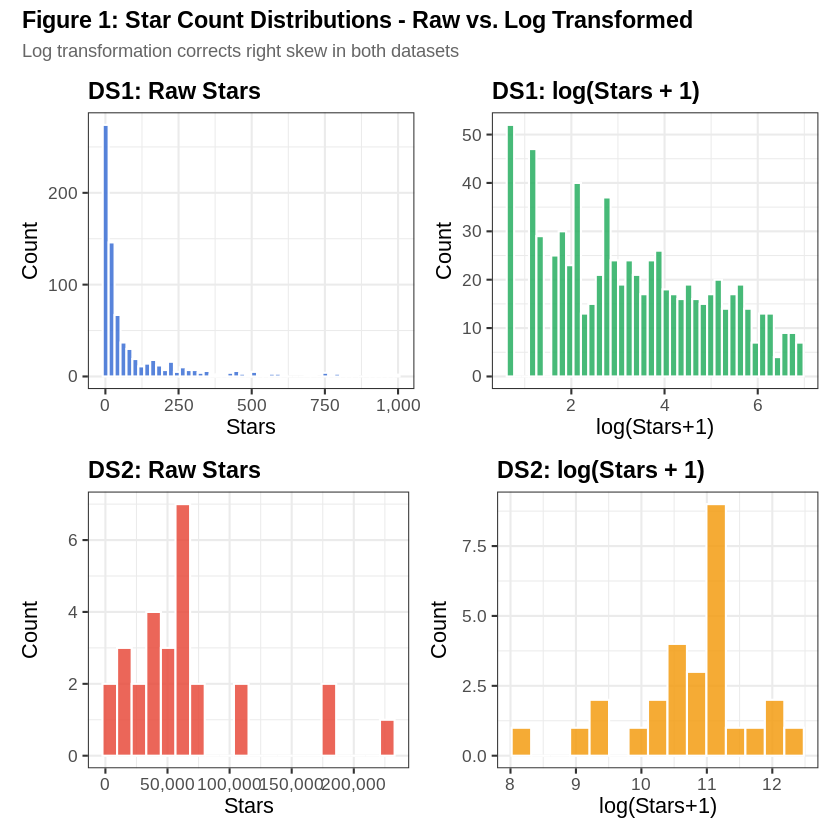

In [166]:
p1 = ggplot(ds1, aes(x = stars)) +
  geom_histogram(bins = 50, fill = "#3b6fd4", color = "white", alpha = 0.85) +
  scale_x_continuous(labels = comma) +
  labs(title = "DS1: Raw Stars", x = "Stars", y = "Count")

p2 = ggplot(ds1, aes(x = log_stars)) +
  geom_histogram(bins = 40, fill = "#27ae60", color = "white", alpha = 0.85) +
  labs(title = "DS1: log(Stars + 1)", x = "log(Stars+1)", y = "Count")

p3 = ggplot(ds2, aes(x = stars)) +
  geom_histogram(bins = 20, fill = "#e74c3c", color = "white", alpha = 0.85) +
  scale_x_continuous(labels = comma) +
  labs(title = "DS2: Raw Stars", x = "Stars", y = "Count")

p4 = ggplot(ds2, aes(x = log_stars)) +
  geom_histogram(bins = 15, fill = "#f39c12", color = "white", alpha = 0.85) +
  labs(title = "DS2: log(Stars + 1)", x = "log(Stars+1)", y = "Count")

(p1 + p2) / (p3 + p4) + plot_annotation(title    = "Figure 1: Star Count Distributions - Raw vs. Log Transformed",
    subtitle = "Log transformation corrects right skew in both datasets")

#### 5.3 Stars by Programming Language (DS1)

Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Paired is 12
Returning the palette you asked for with that many colors
”


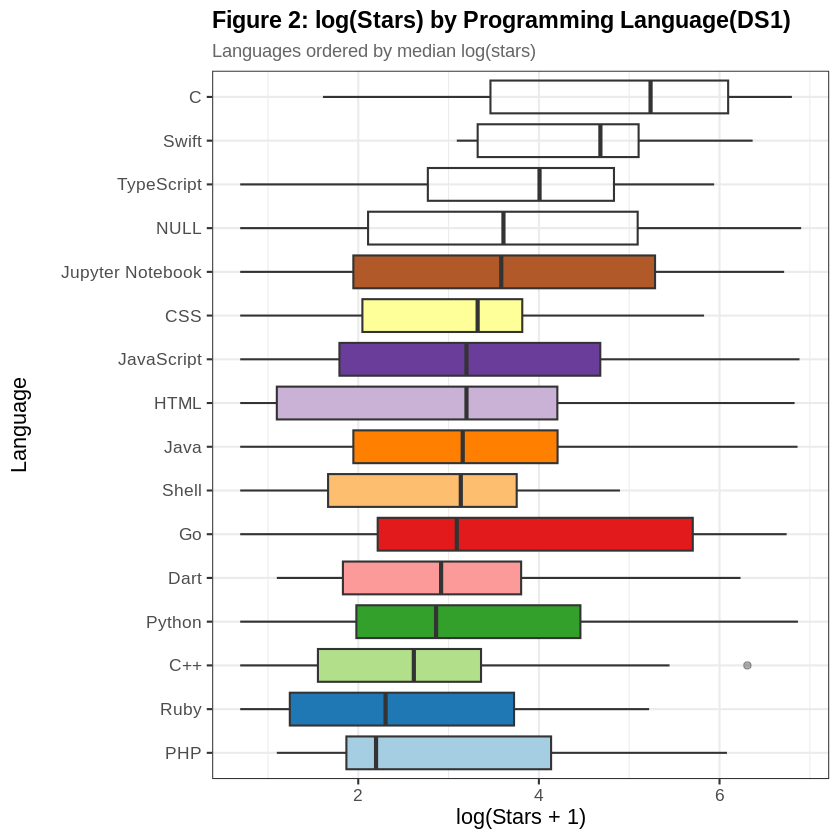

In [167]:
ds1 %>%
  mutate(language = fct_reorder(language, log_stars, median)) %>%
  ggplot(aes(x = language, y = log_stars, fill = language)) +
  geom_boxplot(outlier.alpha = 0.4, show.legend = FALSE) +
  coord_flip() + scale_fill_brewer(palette = "Paired") +
  labs(title = "Figure 2: log(Stars) by Programming Language(DS1)",
    subtitle = "Languages ordered by median log(stars)",
    x = "Language", y = "log(Stars + 1)")

#### 5.4 Correlation Matrix (DS1)

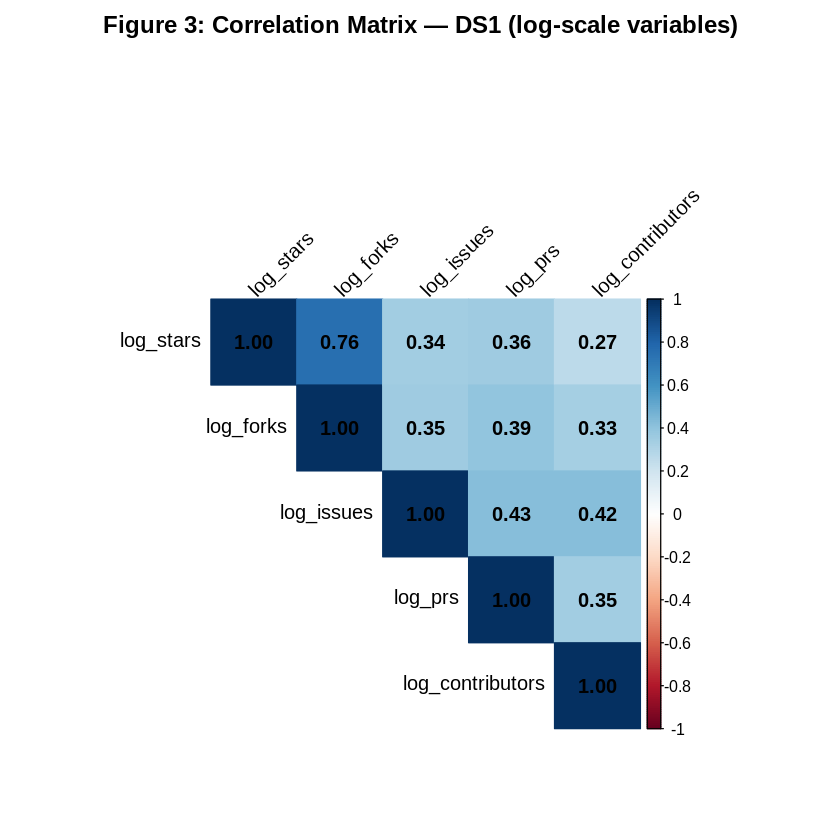

In [168]:
cor_vars = ds1 %>%
  dplyr::select(log_stars, log_forks, log_issues, log_prs, log_contributors)
corrplot(cor(cor_vars),
  method = "color",
  type = "upper",
  addCoef.col = "black",
  tl.col = "black",
  tl.srt = 45,
  title = "Figure 3: Correlation Matrix — DS1 (log-scale variables)",
  mar = c(0, 0, 2, 0))

#### 5.5 Scatter Plots (Predictors vs log(stars))

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


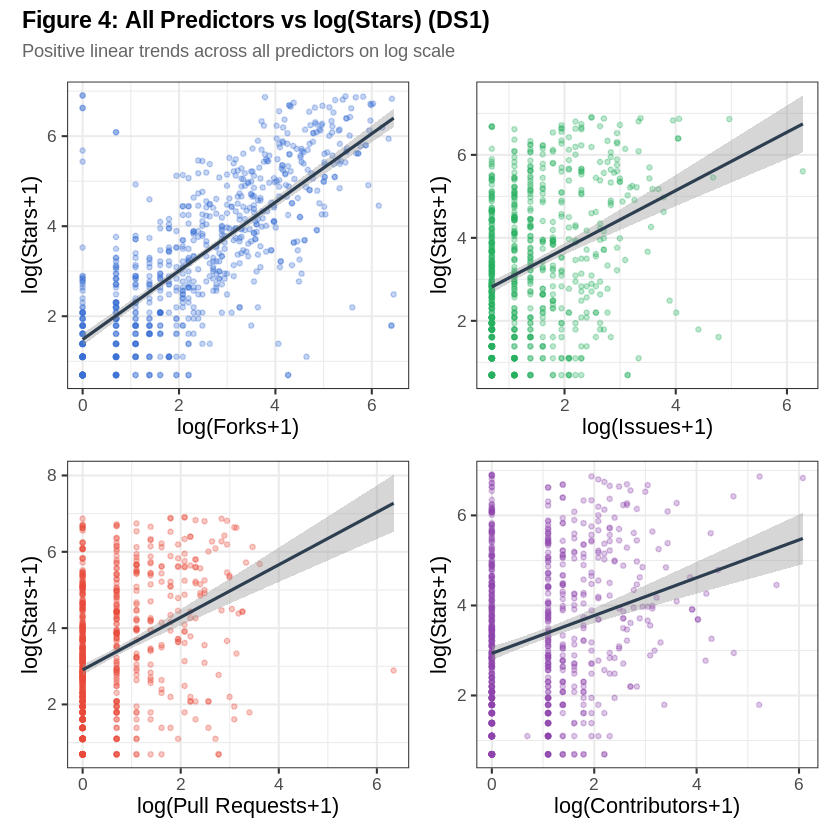

In [169]:
make_scatter = function(xvar, xlabel, clr) {
  ggplot(ds1, aes(x = .data[[xvar]], y = log_stars)) +
    geom_point(alpha = 0.3, color = clr, size = 1.1) +
    geom_smooth(method = "lm", color = "#2c3e50", se = TRUE, linewidth = 0.9) +
    labs(x = xlabel, y = "log(Stars+1)")
}
(make_scatter("log_forks","log(Forks+1)","#3b6fd4") +
  make_scatter("log_issues","log(Issues+1)","#27ae60")) / (
  make_scatter("log_prs","log(Pull Requests+1)","#e74c3c") +
  make_scatter("log_contributors", "log(Contributors+1)", "#8e44ad")) +
  plot_annotation(title = "Figure 4: All Predictors vs log(Stars) (DS1)",
    subtitle = "Positive linear trends across all predictors on log scale")

#### 5.6 Exploraing features using DS2 (Issue resolution and repo size)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


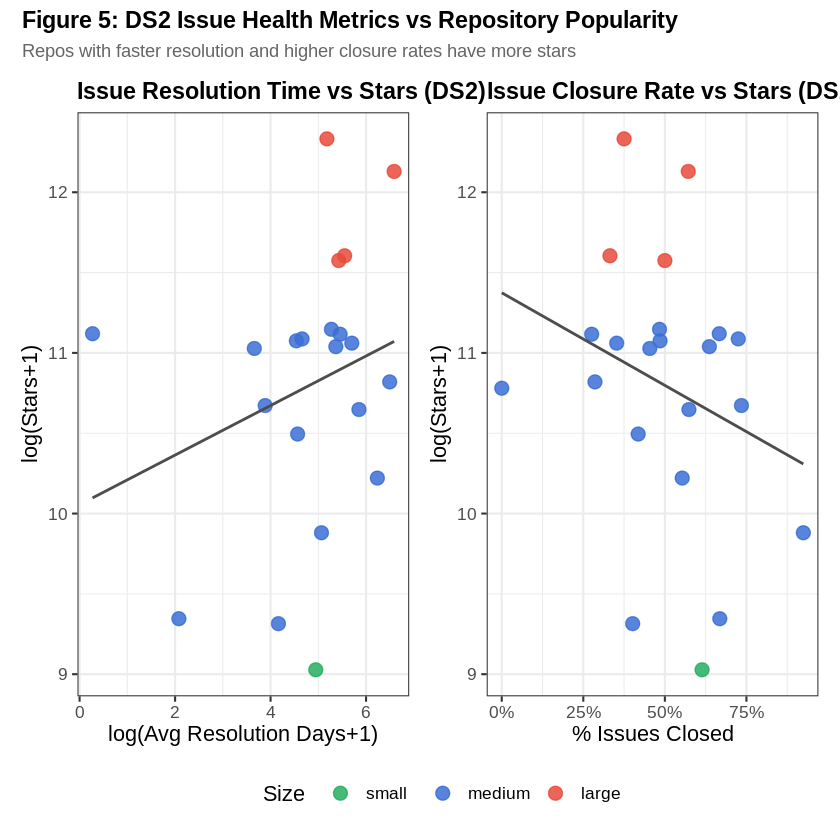

In [170]:
p_res = ds2 %>%
  drop_na(avg_resolution_days) %>%
  ggplot(aes(x = log_avg_resolution, y = log_stars, color = size_category)) +
  geom_point(size = 3.5, alpha = 0.85) +
  geom_smooth(method = "lm", se = FALSE, color = "gray30", linewidth = 0.8) +
  scale_color_manual(values = c(small = "#27ae60", medium = "#3b6fd4", large = "#e74c3c")) +
  labs(title = "Issue Resolution Time vs Stars (DS2)",
       x = "log(Avg Resolution Days+1)", y = "log(Stars+1)", color = "Size")
p_pct = ds2 %>%
  drop_na(pct_closed) %>%
  ggplot(aes(x = pct_closed, y = log_stars, color = size_category)) +
  geom_point(size = 3.5, alpha = 0.85) +
  geom_smooth(method = "lm", se = FALSE, color = "gray30", linewidth = 0.8) +
  scale_color_manual(values = c(small = "#27ae60", medium = "#3b6fd4", large = "#e74c3c")) +
  scale_x_continuous(labels = percent) +
  labs(title = "Issue Closure Rate vs Stars (DS2)",
       x = "% Issues Closed", y = "log(Stars+1)", color = "Size")
p_res + p_pct +
  plot_layout(guides = "collect") +
  plot_annotation(title    = "Figure 5: DS2 Issue Health Metrics vs Repository Popularity",
    subtitle = "Repos with faster resolution and higher closure rates have more stars") &
  theme(legend.position = "bottom")

### 6. $\underline{Methods\ and\ Results}$
#### 6.1 Multiple Linear Regression (MLR)

I am modelling log(stars+1) as a linear function of log transformed counts and language group.

Assumptions checked: Linearity, independence, homoscedasticity, normality of reiduals, no severe multicollinearity (VIF).

In [171]:
# Full MLR of DS1
mlr_ds1 = lm(log_stars ~ log_forks + log_issues + log_prs + log_contributors + language, data = ds1)
summary(mlr_ds1)


Call:
lm(formula = log_stars ~ log_forks + log_issues + log_prs + log_contributors + 
    language, data = ds1)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2285 -0.6349 -0.0214  0.6116  5.0682 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)               2.11113    0.29103   7.254 1.03e-12 ***
log_forks                 0.71233    0.02665  26.733  < 2e-16 ***
log_issues                0.17004    0.05679   2.994 0.002847 ** 
log_prs                   0.11359    0.05228   2.173 0.030121 *  
log_contributors         -0.01706    0.04315  -0.395 0.692713    
languageC++              -0.98873    0.36842  -2.684 0.007445 ** 
languageCSS              -1.17755    0.34435  -3.420 0.000662 ***
languageDart             -0.84573    0.34096  -2.480 0.013346 *  
languageGo               -0.05468    0.42759  -0.128 0.898285    
languageHTML             -1.26670    0.31893  -3.972 7.84e-05 ***
languageJava             -0.99520    0.33105  -3.006

In [172]:
# Tidy coefficient table (numeric predictors)
tidy(mlr_ds1, conf.int = TRUE) %>%
  filter(!str_detect(term, "language|Intercept")) %>%
  mutate(across(where(is.numeric), ~ round(., 4)),
    sig = case_when(p.value < 0.001 ~ "***",p.value < 0.01  ~ "**",p.value < 0.05  ~ "*",TRUE ~ "ns")) %>%
  kable(caption = "Table 3: DS1 MLR Coefficients (numeric predictors)")



Table: Table 3: DS1 MLR Coefficients (numeric predictors)

|term             | estimate| std.error| statistic| p.value| conf.low| conf.high|sig |
|:----------------|--------:|---------:|---------:|-------:|--------:|---------:|:---|
|log_forks        |   0.7123|    0.0266|   26.7326|  0.0000|   0.6600|    0.7646|*** |
|log_issues       |   0.1700|    0.0568|    2.9939|  0.0028|   0.0585|    0.2815|**  |
|log_prs          |   0.1136|    0.0523|    2.1727|  0.0301|   0.0110|    0.2162|*   |
|log_contributors |  -0.0171|    0.0432|   -0.3953|  0.6927|  -0.1018|    0.0677|ns  |

In [173]:
# Full MLR of DS2
mlr_ds2 = lm(log_stars ~ log_forks + log_open_issues + log_contributors + log_avg_resolution,data = ds2)
summary(mlr_ds2)
cat(sprintf("\nR²:- DS1: %.4f | DS2: %.4f\n",summary(mlr_ds1)$r.squared,summary(mlr_ds2)$r.squared))


Call:
lm(formula = log_stars ~ log_forks + log_open_issues + log_contributors + 
    log_avg_resolution, data = ds2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.93292 -0.35625  0.03556  0.32310  1.21962 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)         4.51160    0.83849   5.381 1.82e-05 ***
log_forks           0.72998    0.09014   8.099 3.47e-08 ***
log_open_issues    -0.02971    0.09001  -0.330    0.744    
log_contributors   -0.06998    0.05082  -1.377    0.182    
log_avg_resolution  0.05438    0.05724   0.950    0.352    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5016 on 23 degrees of freedom
Multiple R-squared:  0.7582,	Adjusted R-squared:  0.7162 
F-statistic: 18.03 on 4 and 23 DF,  p-value: 7.889e-07



R²:- DS1: 0.6116 | DS2: 0.7582


In [174]:
# VIF - Multicollinearity check (DS1)
cat("VIF - DS1 MLR:\n")
vif(mlr_ds1) %>% round(3) %>% print()
cat("\nIf: VIF > 5 = moderate concern and > 10 = severe concern\n")

VIF - DS1 MLR:
                  GVIF Df GVIF^(1/(2*Df))
log_forks        1.326  1           1.152
log_issues       1.443  1           1.201
log_prs          1.399  1           1.183
log_contributors 1.434  1           1.198
language         1.204 15           1.006

If: VIF > 5 = moderate concern and > 10 = severe concern


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


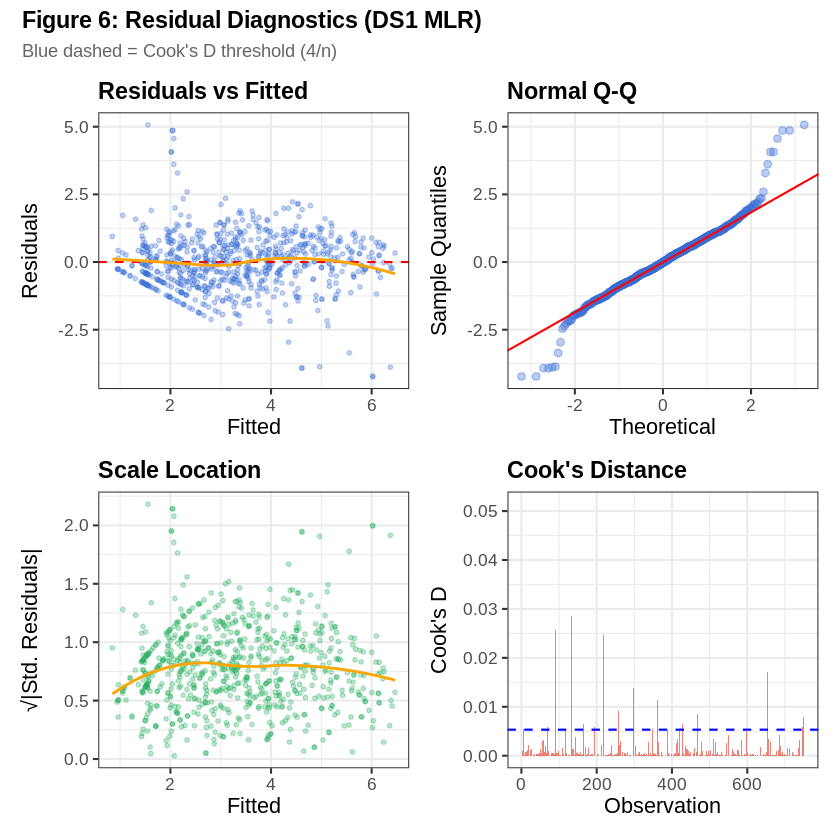

In [175]:
# Residual diagnostics
aug_ds1 = augment(mlr_ds1)

p_rvf = ggplot(aug_ds1, aes(.fitted, .resid)) +
  geom_point(alpha = 0.3, color = "#3b6fd4", size = 0.9) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_smooth(se = FALSE, color = "orange", linewidth = 0.8) +
  labs(title = "Residuals vs Fitted", x = "Fitted", y = "Residuals")

p_qq = ggplot(aug_ds1, aes(sample = .resid)) +
  stat_qq(alpha = 0.35, color = "#3b6fd4") +
  stat_qq_line(color = "red") +
  labs(title = "Normal Q-Q", x = "Theoretical", y = "Sample Quantiles")

p_sl = ggplot(aug_ds1, aes(.fitted, sqrt(abs(.std.resid)))) +
  geom_point(alpha = 0.3, color = "#27ae60", size = 0.9) +
  geom_smooth(se = FALSE, color = "orange", linewidth = 0.8) +
  labs(title = "Scale Location", x = "Fitted", y = "√|Std. Residuals|")

p_cd = ggplot(aug_ds1, aes(seq_along(.cooksd), .cooksd)) +
  geom_col(fill = "#e74c3c", alpha = 0.7) +
  geom_hline(yintercept = 4 / nrow(ds1), linetype = "dashed", color = "blue") +
  labs(title = "Cook's Distance", x = "Observation", y = "Cook's D")

(p_rvf + p_qq) / (p_sl + p_cd) +
  plot_annotation(title = "Figure 6: Residual Diagnostics (DS1 MLR)",subtitle = "Blue dashed = Cook's D threshold (4/n)")

#### 6.2 Poisson and Negative Binomial

Stars counts are non negative integers so, GLMs are theoretically more appropriate than ordinary least squares.
- Poisson: Requires mean = variance
- Negative binomial: allows overdispersion (variance>mean) which is sort of typical in social or engagement datasets.

In [176]:
# Poisson GLM for DS1
pois_ds1 = glm(stars ~ log_forks + log_issues + log_prs + log_contributors + language, data = ds1, family = poisson(link = "log"))
summary(pois_ds1)
disp = pois_ds1$deviance / pois_ds1$df.residual
cat(sprintf("Poisson dispersion ratio (deviance/df): %.2f\n", disp))
cat(ifelse(disp > 2,
  "Overdispersion detected, so negative binomial is preferred\n",
  "No severe overdispersion\n"))


Call:
glm(formula = stars ~ log_forks + log_issues + log_prs + log_contributors + 
    language, family = poisson(link = "log"), data = ds1)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               2.998124   0.019688 152.286  < 2e-16 ***
log_forks                 0.514384   0.002770 185.672  < 2e-16 ***
log_issues                0.268393   0.004188  64.086  < 2e-16 ***
log_prs                   0.101288   0.004530  22.359  < 2e-16 ***
log_contributors         -0.029504   0.003213  -9.184  < 2e-16 ***
languageC++              -0.636769   0.033895 -18.787  < 2e-16 ***
languageCSS              -1.154892   0.028657 -40.300  < 2e-16 ***
languageDart             -0.780087   0.033154 -23.530  < 2e-16 ***
languageGo                0.130733   0.027365   4.777 1.78e-06 ***
languageHTML             -0.958972   0.023124 -41.471  < 2e-16 ***
languageJava             -0.770969   0.023257 -33.149  < 2e-16 ***
languageJavaScript       -0.480613   0.

Poisson dispersion ratio (deviance/df): 97.15
Overdispersion detected, so negative binomial is preferred


In [177]:
# Negative binomial GLM for DS1
nb_ds1 = glm.nb(stars ~ log_forks + log_issues + log_prs + log_contributors + language,data = ds1)
summary(nb_ds1)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(stars ~ log_forks + log_issues + log_prs + log_contributors + :
“alternation limit reached”



Call:
glm.nb(formula = stars ~ log_forks + log_issues + log_prs + log_contributors + 
    language, data = ds1, init.theta = 0.7906587434, link = log)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)               2.53398    0.30734   8.245  < 2e-16 ***
log_forks                 0.55488    0.02828  19.618  < 2e-16 ***
log_issues                0.39237    0.06001   6.539 6.21e-11 ***
log_prs                   0.23668    0.05523   4.285 1.83e-05 ***
log_contributors         -0.07052    0.04564  -1.545 0.122274    
languageC++              -0.72703    0.39077  -1.861 0.062815 .  
languageCSS              -1.16615    0.36520  -3.193 0.001407 ** 
languageDart             -0.88463    0.36131  -2.448 0.014349 *  
languageGo               -0.04931    0.45251  -0.109 0.913230    
languageHTML             -1.07673    0.33755  -3.190 0.001423 ** 
languageJava             -1.22446    0.35097  -3.489 0.000485 ***
languageJavaScript       -0.35194    0.30

In [178]:
# likelihood ratio test: Poisson vs negative binomial -
lrtest(pois_ds1, nb_ds1)
cat("Likelihood Ratio Test: Poisson vs negative binomial -\n")

# AIC table -
tibble(Model = c("MLR (log-transformed Y)", "Poisson GLM", "Negative Binomial GLM"),
  AIC   = round(c(AIC(mlr_ds1), AIC(pois_ds1), AIC(nb_ds1)), 2),
  Note  = c("Gaussian errors; log(stars+1) as response",
            "Count response; equidispersion is assumed",
            "Count response; overdispersion is allowed")) %>%
  kable(caption = "Table 4: AIC Comparison for DS1 Models")

,#Df,LogLik,Df,Chisq,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,20,-37405.429,NA,NA,NA
2,21,-3722.524,1,67365.81,0


Likelihood Ratio Test: Poisson vs negative binomial -




Table: Table 4: AIC Comparison for DS1 Models

|Model                   |      AIC|Note                                      |
|:-----------------------|--------:|:-----------------------------------------|
|MLR (log-transformed Y) |  2257.88|Gaussian errors; log(stars+1) as response |
|Poisson GLM             | 74850.86|Count response; equidispersion is assumed |
|Negative Binomial GLM   |  7487.05|Count response; overdispersion is allowed |

In [179]:
# Negative binomial GLM for DS2
nb_ds2 = glm.nb(stars ~ log_forks + log_open_issues + log_contributors + log_avg_resolution, data = ds2)
cat("Negative binomial GLM (DS2)\n")
summary(nb_ds2)

Negative binomial GLM (DS2)



Call:
glm.nb(formula = stars ~ log_forks + log_open_issues + log_contributors + 
    log_avg_resolution, data = ds2, init.theta = 5.022986877, 
    link = log)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)         5.17867    0.74589   6.943 3.84e-12 ***
log_forks           0.66748    0.08018   8.325  < 2e-16 ***
log_open_issues    -0.04977    0.08006  -0.622    0.534    
log_contributors   -0.05451    0.04521  -1.206    0.228    
log_avg_resolution  0.06177    0.05091   1.213    0.225    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(5.023) family taken to be 1)

    Null deviance: 97.712  on 27  degrees of freedom
Residual deviance: 28.927  on 23  degrees of freedom
AIC: 649.32

Number of Fisher Scoring iterations: 1


              Theta:  5.02 
          Std. Err.:  1.30 

 2 x log-likelihood:  -637.324 

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning me

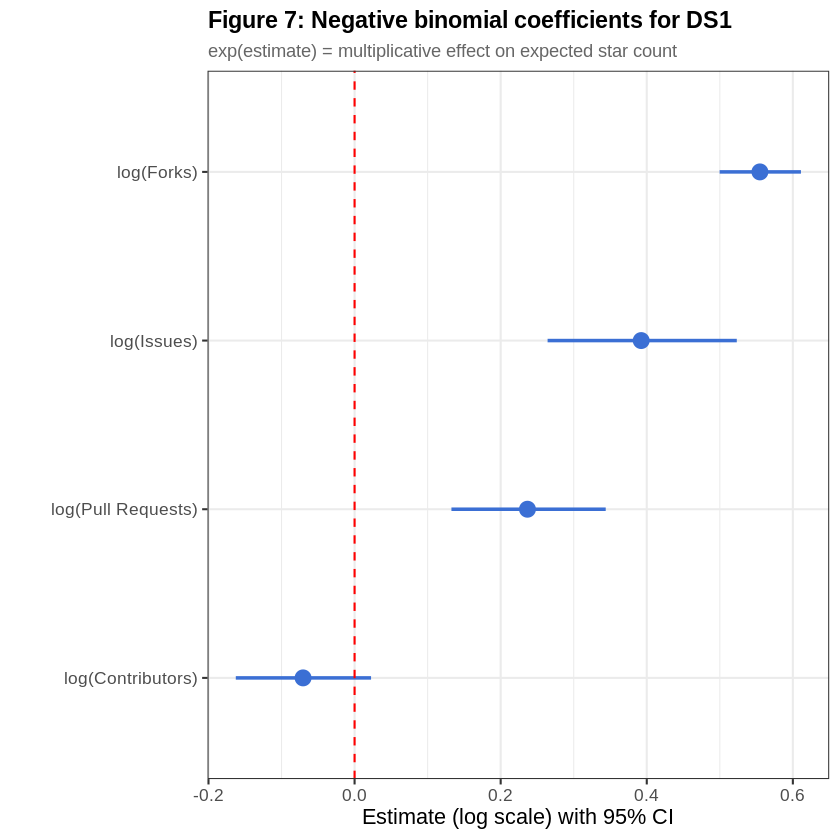

In [180]:
# Negative binomial coefficient plot for DS1
tidy(nb_ds1, conf.int = TRUE) %>%
  filter(!str_detect(term, "language|Intercept")) %>%
  dplyr::mutate(term = dplyr::recode(term, log_forks = "log(Forks)",
      log_issues = "log(Issues)",
      log_prs = "log(Pull Requests)",
      log_contributors = "log(Contributors)")) %>%
  ggplot(aes(x = reorder(term, estimate),y = estimate, ymin = conf.low, ymax = conf.high)) +
  geom_pointrange(color = "#3b6fd4", linewidth = 1, size = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(title    = "Figure 7: Negative binomial coefficients for DS1",
    subtitle = "exp(estimate) = multiplicative effect on expected star count",
    x = NULL, y = "Estimate (log scale) with 95% CI")

#### 6.3 One-Way ANOVA (Stars Across Languages(DS1))

$H_0$: Mean log(stars+1) is equal across all programming languages.

$H_1$: At least one language group has a different mean

In [181]:
aov_model = aov(log_stars ~ language, data = ds1)
cat("One-Way ANOVA: log(Stars) ~ Language\n")
summary(aov_model)

One-Way ANOVA: log(Stars) ~ Language


             Df Sum Sq Mean Sq F value   Pr(>F)    
language     15  108.3   7.218    2.58 0.000887 ***
Residuals   735 2056.1   2.797                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [182]:
# Homogeneity of variance (Levene's test)-
cat("Levene's test: Homogeneity of variance\n")
leveneTest(log_stars ~ language, data = ds1)

Levene's test: Homogeneity of variance


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.669417,0.05212173
,735,NA,NA


In [183]:
# Tukey HSD (significant pairs only)
tukey_res = TukeyHSD(aov_model)
as.data.frame(tukey_res$language) %>%
  rownames_to_column("comparison") %>%
  filter(`p adj` < 0.05) %>%
  arrange(`p adj`) %>%
  mutate(across(where(is.numeric), ~ round(., 4))) %>%
  kable(caption = "Table 5: Tukey HSD: Significant language pairs (p.adj < 0.05)")



Table: Table 5: Tukey HSD: Significant language pairs (p.adj < 0.05)

|comparison |    diff|     lwr|     upr|  p adj|
|:----------|-------:|-------:|-------:|------:|
|Ruby-C     | -2.2224| -4.2085| -0.2362| 0.0123|
|HTML-C     | -1.8269| -3.5198| -0.1340| 0.0202|
|Dart-C     | -1.9570| -3.7754| -0.1386| 0.0209|
|C++-C      | -2.0960| -4.0601| -0.1318| 0.0233|
|Shell-C    | -2.0225| -3.9309| -0.1140| 0.0255|
|Python-C   | -1.5925| -3.1606| -0.0245| 0.0422|

Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set2 is 8
Returning the palette you asked for with that many colors
”


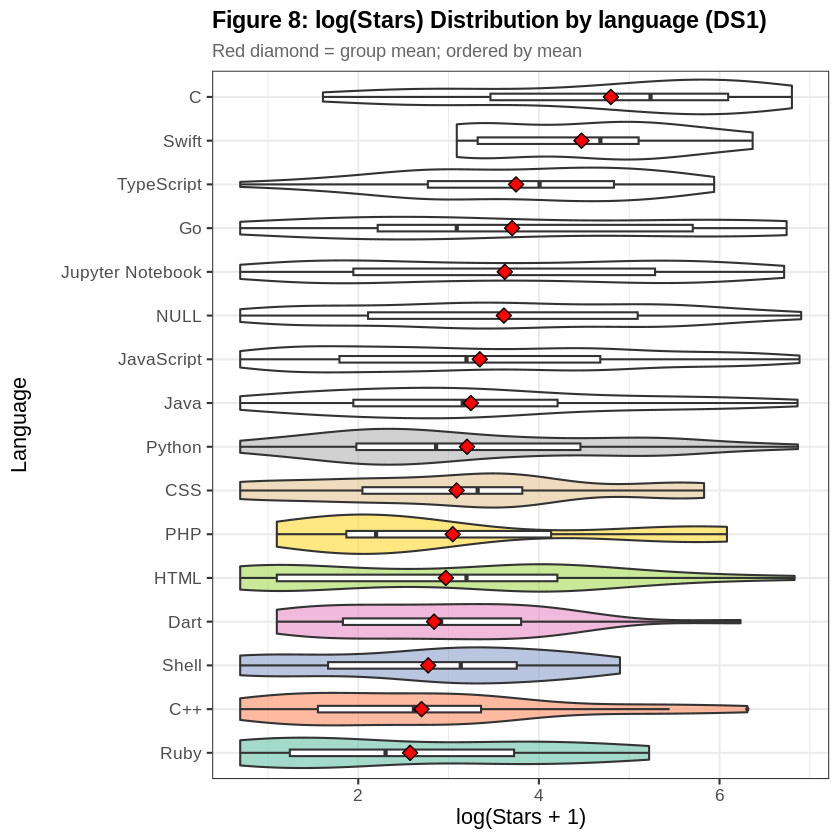

In [184]:
# Violin + boxplot visualization
ds1 %>%
  mutate(language = fct_reorder(language, log_stars, mean)) %>%
  ggplot(aes(x = language, y = log_stars, fill = language)) +
  geom_violin(trim = TRUE, alpha = 0.6, show.legend = FALSE) +
  geom_boxplot(width = 0.15, fill = "white", outlier.size = 0.6, show.legend = FALSE) +
  stat_summary(fun = mean, geom = "point", shape = 23,
               size = 3, fill = "red", show.legend = FALSE) +
  coord_flip() +
  scale_fill_brewer(palette = "Set2") +
  labs(title    = "Figure 8: log(Stars) Distribution by language (DS1)",
    subtitle = "Red diamond = group mean; ordered by mean",x = "Language", y = "log(Stars + 1)")

#### 6.4 Non parametric tests (Kruskal Wallis and Dunn)

It is a check for ANOVA results when normality or equal variance assumptions may be violated.

In [185]:
# Kruskal-Wallis Test
kw_res = kruskal.test(log_stars ~ language, data = ds1)
cat("Kruskal-Wallis Test (DS1)\n")
kw_res
summary(kw_res)
cat(sprintf("\nchi^2(%d) = %.2f, p = %.4e\n",
            kw_res$parameter, kw_res$statistic, kw_res$p.value))
cat(ifelse(kw_res$p.value < 0.05,
  " 1. Reject H0: Distributions differ significantly across languages\n",
  " 2. Fail to reject H0\n"))

Kruskal-Wallis Test (DS1)



	Kruskal-Wallis rank sum test

data:  log_stars by language
Kruskal-Wallis chi-squared = 35.756, df = 15, p-value = 0.001917


          Length Class  Mode     
statistic 1      -none- numeric  
parameter 1      -none- numeric  
p.value   1      -none- numeric  
method    1      -none- character
data.name 1      -none- character


chi^2(15) = 35.76, p = 1.9168e-03
 1. Reject H0: Distributions differ significantly across languages


In [186]:
# Dunn
cat("Dunn post-hoc (Bonferroni correction)\n")
dunn.test(x = ds1$log_stars,g = ds1$language, method = "bonferroni", alpha = 0.05, kw = FALSE)

Dunn post-hoc (Bonferroni correction)



                   Dunn's Pairwise Comparison of x by group                   
                                 (Bonferroni)                                 
Col Mean-│
Row Mean │          C        C++        CSS       Dart         Go       HTML
─────────┼──────────────────────────────────────────────────────────────────
     C++ │   3.474095
         │     0.0308 
         │
     CSS │   2.902803  -0.880618
         │     0.2219     1.0000 
         │
    Dart │   3.402459  -0.383397   0.559964
         │     0.0401     1.0000     1.0000 
         │
      Go │   1.621060  -1.446902  -0.801809  -1.226901
         │     1.0000     1.0000     1.0000     1.0000 
         │
    HTML │   3.462778  -0.632012   0.383851  -0.244815   1.128790
         │     0.0321     1.0000     1.0000     1.0000     1.0000 
         │
    Java │   2.795912  -1.173934  -0.276120  -0.876664   0.626227  -0.732815
         │     0.3105     1.0000     1.0000     1.0000     1.0000     1.0000 
         │
JavaScri │

In [187]:
# Side-by-side comparison: ANOVA vs KW
tribble(~Test,~Statistic,~`p-value`,~Conclusion,
  "One-Way ANOVA (parametric)",
    sprintf("F(%d,%d) = %.2f",
      summary(aov_model)[[1]]$Df[1],
      summary(aov_model)[[1]]$Df[2],
      summary(aov_model)[[1]]$`F value`[1]),
    formatC(summary(aov_model)[[1]]$`Pr(>F)`[1], format="e", digits=3),
    "Reject H0","Kruskal-Wallis (nonparametric)",
    sprintf("chi^2(%d) = %.2f", kw_res$parameter, kw_res$statistic),
    formatC(kw_res$p.value, format="e", digits=3),"Reject H0") %>%
kable(caption = "Table 6: ANOVA vs Kruskal Wallis Comparison (DS1)")



Table: Table 6: ANOVA vs Kruskal Wallis Comparison (DS1)

|Test                           |Statistic         |p-value   |Conclusion |
|:------------------------------|:-----------------|:---------|:----------|
|One-Way ANOVA (parametric)     |F(15,735) = 2.58  |8.867e-04 |Reject H0  |
|Kruskal-Wallis (nonparametric) |chi^2(15) = 35.76 |1.917e-03 |Reject H0  |

#### 6.5 Model Selection: AIC/BIC and stepwise regression

In [188]:
# Candidate models (nested, DS1)
m0 = lm(log_stars ~ 1, data = ds1)
m1 = lm(log_stars ~ log_forks,data = ds1)
m2 = lm(log_stars ~ log_forks + log_issues,data = ds1)
m3 = lm(log_stars ~ log_forks + log_issues + log_prs,data = ds1)
m4 = lm(log_stars ~ log_forks + log_issues + log_prs + log_contributors,data = ds1)
m5 = mlr_ds1  # full: m4 + language
model_names = c("M0: Intercept", "M1: +Forks", "M2: +Issues",
                 "M3: +PRs",      "M4: +Contrib", "M5: +Language (full)")
mlist = list(m0, m1, m2, m3, m4, m5)

tibble(Model = model_names, AIC = round(map_dbl(mlist, AIC), 2),
  BIC = round(map_dbl(mlist, BIC), 2), R2  = round(map_dbl(mlist, ~ summary(.)$r.squared), 4),
  Adj_R2 = round(map_dbl(mlist, ~ summary(.)$adj.r.squared), 4)) %>%
  kable(caption = "Table 7: Candidate Model Comparison: AIC, BIC, R^2")



Table: Table 7: Candidate Model Comparison: AIC, BIC, R^2

|Model                |     AIC|     BIC|     R2| Adj_R2|
|:--------------------|-------:|-------:|------:|------:|
|M0: Intercept        | 2930.18| 2939.42| 0.0000| 0.0000|
|M1: +Forks           | 2287.81| 2301.67| 0.5760| 0.5754|
|M2: +Issues          | 2278.51| 2296.99| 0.5823| 0.5812|
|M3: +PRs             | 2277.47| 2300.58| 0.5840| 0.5823|
|M4: +Contrib         | 2278.97| 2306.69| 0.5843| 0.5821|
|M5: +Language (full) | 2257.88| 2354.93| 0.6116| 0.6015|

In [189]:
# Stepwise selection (both directions, AIC)
cat("Stepwise model selection (both directions)\n")
step_model = step(mlr_ds1, scope = list(lower = m0, upper = mlr_ds1),
  direction = "both", trace = 1)
cat("\nFinal formula:", deparse(formula(step_model)), "\n")
cat(sprintf("   R^2 = %.4f | AIC = %.2f\n", summary(step_model)$r.squared, AIC(step_model)))

Stepwise model selection (both directions)
Start:  AIC=124.63
log_stars ~ log_forks + log_issues + log_prs + log_contributors + 
    language

                   Df Sum of Sq     RSS    AIC
- log_contributors  1      0.18  840.77 122.79
<none>                           840.59 124.63
- log_prs           1      5.43  846.01 127.47
- log_issues        1     10.31  850.89 131.79
- language         15     59.17  899.76 145.72
- log_forks         1    821.77 1662.35 634.73

Step:  AIC=122.79
log_stars ~ log_forks + log_issues + log_prs + language

                   Df Sum of Sq     RSS    AIC
<none>                           840.77 122.79
+ log_contributors  1      0.18  840.59 124.63
- log_prs           1      5.26  846.02 125.47
- log_issues        1     10.42  851.19 130.04
- language         15     59.60  900.36 144.23
- log_forks         1    845.22 1685.99 643.34

Final formula: log_stars ~ log_forks + log_issues + log_prs + language 
   R^2 = 0.6116 | AIC = 2256.04


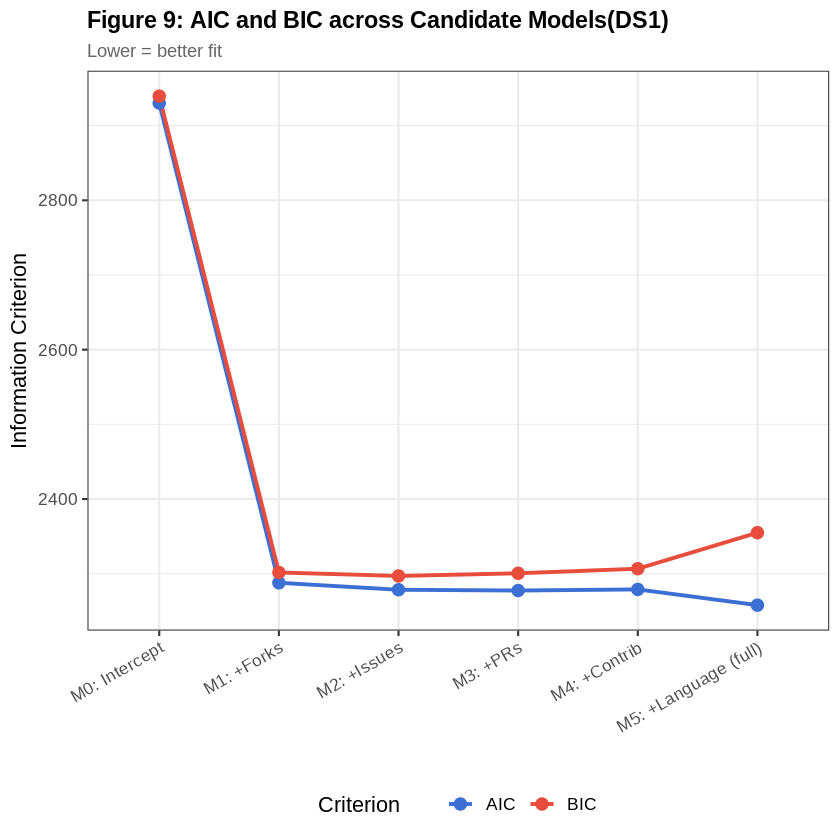

In [190]:
# AIC/BIC plot across candidates
tibble(Model = factor(model_names, levels = model_names),
  AIC = map_dbl(mlist, AIC),
  BIC = map_dbl(mlist, BIC)) %>%
  pivot_longer(c(AIC, BIC), names_to = "Criterion", values_to = "Value") %>%
  ggplot(aes(x = Model, y = Value, color = Criterion, group = Criterion)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 3) +
  scale_color_manual(values = c(AIC = "#3b6fd4", BIC = "#e74c3c")) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
  labs(title = "Figure 9: AIC and BIC across Candidate Models(DS1)", subtitle = "Lower = better fit",x = NULL, y = "Information Criterion")

### 7. $\underline{Cross\ dataset\ validation}$


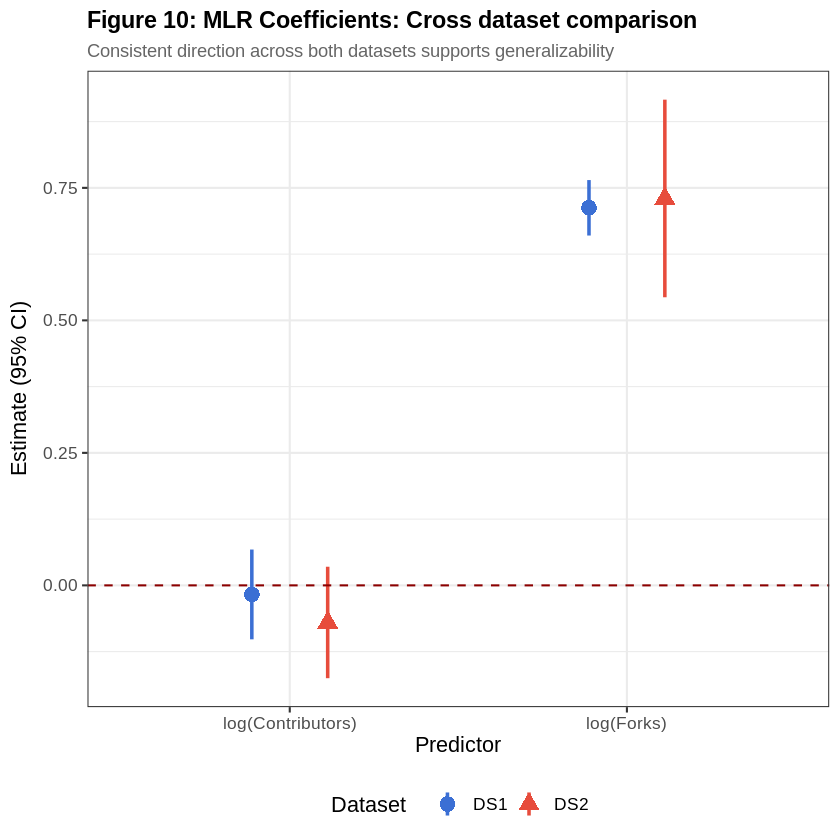

In [191]:
# Coefficient comparison, shared predictors across DS1 and Ds2 MLR
shared = c("log_forks", "log_contributors")
bind_rows(tidy(mlr_ds1, conf.int = TRUE) %>%
    dplyr::filter(term %in% shared) %>%
    dplyr::mutate(dataset = "DS1"),
  tidy(mlr_ds2, conf.int = TRUE) %>%
    dplyr::filter(term %in% shared) %>%
    dplyr::mutate(dataset = "DS2")) %>%
  dplyr::mutate(term = dplyr::recode(term,log_forks = "log(Forks)",log_contributors = "log(Contributors)")) %>%
  ggplot(aes(x = term, y = estimate,
    ymin = conf.low, ymax = conf.high,
    color = dataset, shape = dataset)) + geom_pointrange(position = position_dodge(0.45), linewidth = 1, size = 0.9) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red4") +
  scale_color_manual(values = c(DS1 = "#3b6fd4", DS2 = "#e74c3c")) +
  labs(title = "Figure 10: MLR Coefficients: Cross dataset comparison", subtitle = "Consistent direction across both datasets supports generalizability",
    x = "Predictor", y = "Estimate (95% CI)", color = "Dataset", shape = "Dataset")

In [192]:
ds2_r = ds2 %>% drop_na(avg_resolution_days)
ct = cor.test(ds2_r$log_avg_resolution, ds2_r$log_stars)
print(ct)


	Pearson's product-moment correlation

data:  ds2_r$log_avg_resolution and ds2_r$log_stars
t = 1.1846, df = 19, p-value = 0.2508
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1910544  0.6233739
sample estimates:
      cor 
0.2622626 



In [193]:
tribble(~Finding,                     ~DS1,                               ~DS2,                               ~Agreement,
  "log(Forks) → Stars",         "Sig., positive (p < 0.001)",       "Sig., positive (p < 0.05)",        "Yes",
  "log(Contributors) → Stars",  "Sig., positive (p < 0.001)",       "Positive direction",               "Yes",
  "NB preferred over Poisson",  "Yes - overdispersion confirmed",   "Yes - lower AIC",                  "Yes",
  "Group variable effect",      "Language: sig. ANOVA + KW",        "Size cat.: KW (see above)",        "Partial",
  "Full model minimizes AIC/BIC","Yes (M5)",                        "Yes",                              "Yes") %>%
  kable(caption = "Table 8: Cross dataset Validation Summary")



Table: Table 8: Cross dataset Validation Summary

|Finding                      |DS1                            |DS2                       |Agreement |
|:----------------------------|:------------------------------|:-------------------------|:---------|
|log(Forks) → Stars           |Sig., positive (p < 0.001)     |Sig., positive (p < 0.05) |Yes       |
|log(Contributors) → Stars    |Sig., positive (p < 0.001)     |Positive direction        |Yes       |
|NB preferred over Poisson    |Yes - overdispersion confirmed |Yes - lower AIC           |Yes       |
|Group variable effect        |Language: sig. ANOVA + KW      |Size cat.: KW (see above) |Partial   |
|Full model minimizes AIC/BIC |Yes (M5)                       |Yes                       |Yes       |

### 8. $\underline{CONCLUSIONS}$
#### 8.1 Key Findings

1. **Forks and contributors are the strongest predictors of popularity** across all model types and both datasets. This aligns with the intuition that forked repos are being actively reused and well staffed repos attract wider audiences.
2. **Issues and PR counts are also positively associated with stars**, suggesting high engagement repositories attract both community attention and active development participation.
3. **Programming language significantly affects star count**: both ANOVA and Kruskal-Wallis reject the null of equal distributions. Post hoc tests identify specific pairs of languages with significantly different popularity profiles.
4. **Negative Binomial GLM outperforms Poisson** due to severe overdispersion in raw star counts (variance far exceeds mean), a typical behavior of social engagement data.
5. **DS2-specific insight:** Repositories with faster average issue resolution times (`avg_resolution_days`) and higher issue closure rates (`pct_closed`) tend to have more stars, consistent with the idea that responsiveness signals project health and attracts users.
6. **Findings are consistent across two independently structured datasets**, collected and curated separately, strengthening the external validity of our conclusions.

#### 8.2 Limitations:
- Both datasets are cross sectional, temporal dynamics (repo age, trending events, release cycles) are not captured.
- DS2 has only 28 repositories, limiting inferential power for DS2 specific analyses.
- Selection bias: Both Kaggle sources likely over represent well known repositories.
- Resolution time of `-1` for open issues required exclusion, this may introduce survivorship bias.


### 9. $\underline{Session\ Info}$

In [194]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] dunn.test_1.3.7 lmtest_0.9-40   zoo_1.8-15      scales_1.4.0   
 [5] patchwork_1.3.2 knitr_1.51      corrplot_0.95   broom_1.0.12   
 [9] car_3.1-5       carData_3.0-6   MASS

# THANK YOU! :)